In [233]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

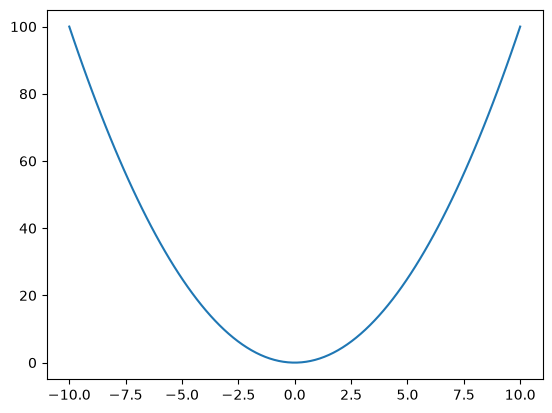

In [234]:
def f(x):
    return x**2  # 5 * x**2 + 4 * x + 5


# Plot the function
x = np.linspace(-10, 10, 100)
y = f(x)
plt.plot(x, y)

In [235]:
f(7.5)

56.25

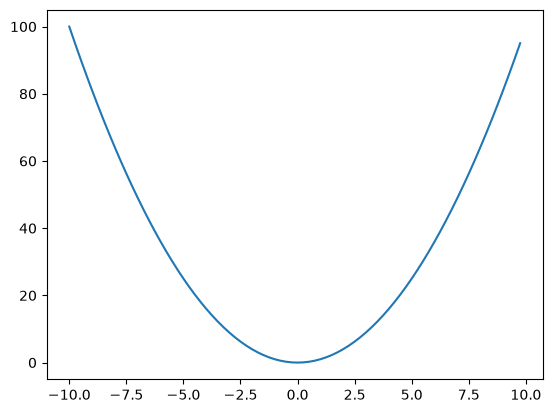

In [236]:
xs = np.arange(-10, 10, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [237]:
h = 0.1
x = 3.0
slope = (f(x + h) - f(x)) / h
print(f"f'({x}) ≈ {slope}")
print(f(x))
print(f(x + h))
print("----------------------------")
x = -3.0
print(f"f({x}) = {f(x)}")
print(f"f({x} + {h}) = {f(x + h)}")
slope = (f(x + h) - f(x)) / h
print(f"f'({x}) ≈ {slope}")

f'(3.0) ≈ 6.100000000000012
9.0
9.610000000000001
----------------------------
f(-3.0) = 9.0
f(-3.0 + 0.1) = 8.41
f'(-3.0) ≈ -5.899999999999999


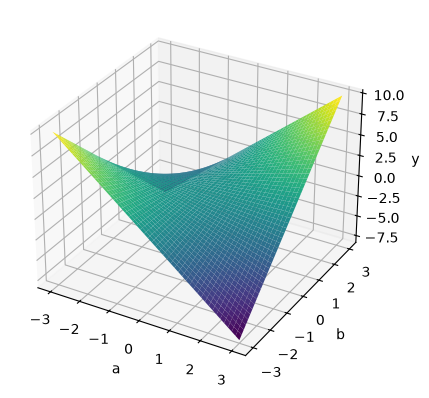

In [238]:
fig = plt.figure()
ax = fig.add_subplot(projection="3d")

a = np.linspace(-3, 3, 50)
b = np.linspace(-3, 3, 50)
A, B = np.meshgrid(a, b)
c = 1.0  # fixed
Y = A * B + c  # a saddle surface

ax.plot_surface(A, B, Y, cmap="viridis")
ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_zlabel("y")
plt.show()

In [239]:
h = 0.001

a = 2.0
b = 3.0
c = 10

y1 = a * b + c
a += h
y2 = (a + h) * b + c

print(f"y1 = {y1}, y2 = {y2}")
slope = (y2 - y1) / h
print(f"∂y/∂a ≈ {slope}")


y1 = 16.0, y2 = 16.006
∂y/∂a ≈ 6.000000000000227


In [240]:
from graphviz import Digraph


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format="svg", rankdir="LR"):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ["LR", "TB"]
    nodes, edges = trace(root)
    dot = Digraph(
        format=format, graph_attr={"rankdir": rankdir}
    )  # , node_attr={'rankdir': 'TB'})

    for n in nodes:
        dot.node(
            name=str(id(n)),
            label="{ %s | data: %.4f | grad: %.4f }" % (n.label, n.data, n.grad),
            shape="record",
        )
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=f" {n._op}")
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [444]:
import math


class Value:
    """stores a single scalar value and its gradient"""

    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self.label = label
        self._prev = set(_children)
        self._op = _op  # the op that produced this node, for graphviz / debugging / etc

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(
            self.data + other.data,
            (self, other),
            "+",
            label=f"{self.label}+{other.label}",
        )

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(
            self.data * other.data,
            (self, other),
            "*",
            label=f"{self.label}*{other.label}",
        )

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), (
            "only supporting int/float powers for now"
        )
        out = Value(
            self.data**other, (self,), f"**{other}", label=f"{self.label}**{other}"
        )

        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad

        out._backward = _backward

        return out

    def relu(self):
        out = Value(max(self.data, 0), (self,), "ReLU", label=f"ReLU({self.label})")

        def _backward():
            self.grad += (out.data > 0) * out.grad

        out._backward = _backward

        return out

    def sigmoid(self):

        s = 1 / (1 + math.exp(-self.data))
        out = Value(s, (self,), "sigmoid", label=f"sigmoid({self.label})")

        def _backward():
            # derivative of sigmoid: s * (1 - s), where s is the output itself
            self.grad += out.data * (1 - out.data) * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), "tanh", label=f"tanh({self.label})")

        def _backward():
            # derivative of tanh: 1 - tanh^2
            self.grad += (1 - out.data**2) * out.grad

        out._backward = _backward

        return out

    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self):  # -self
        return self * -1

    def __radd__(self, other):  # other + self
        return self + other

    def __sub__(self, other):  # self - other
        return self + (-other)

    def __rsub__(self, other):  # other - self
        return other + (-self)

    def __rmul__(self, other):  # other * self
        return self * other

    def __truediv__(self, other):  # self / other
        return self * other**-1

    def __rtruediv__(self, other):  # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

In [242]:
h = 5
x = Value(1.0, label="x")
y = Value(2.0 + h, label="y")
a = x + y
a.label = "a"
b = Value(-1.0, label="b")
c = Value(2.0, label="c")
e = a * b
e.label = "e"
d = e + c
d.label = "d"
sig = d.sigmoid()
sig.label = "sigmoid(d)"
sig.backward()

d = (x + y) * b + c
d = xb + yb + c

dd/dx = b

a = x + y

dd/dx = dd/da * da/dx



d = a * b + c

d = e + c -> 1
dd/dc = 1
dd/de = 1

e = a * b -> 2
de/da = b
de/db = a

dd/da = dd/de * de/da -> chain rule = 1 * de/da = b
dd/db = dd/de * de/db -> chain rule = 1 * de/db = a

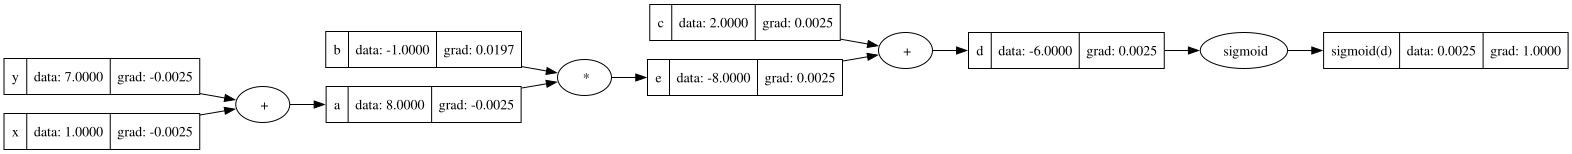

In [243]:
draw_dot(sig)

In [253]:
import random

import torch

In [245]:
h = 5
x = torch.tensor([1.0], requires_grad=True)  # Value(1.0, label="x")
y = torch.tensor([2.0 + h], requires_grad=True)  # Value(2.0 + h, label="y")
a = x + y
b = torch.tensor([-1.0], requires_grad=True)  # Value(-1.0, label="b")
c = torch.tensor([2.0], requires_grad=True)  # Value(2.0, label="c")
e = a * b
d = e + c
sig = d.sigmoid()
sig.backward()

print(f"x.grad = {x.grad}, y.grad = {y.grad}, b.grad = {b.grad}, c.grad = {c.grad}")

x.grad = tensor([-0.0025]), y.grad = tensor([-0.0025]), b.grad = tensor([0.0197]), c.grad = tensor([0.0025])


In [ ]:
d = [1] + [1, 2, 3]
d = [1] + [2] + [3]
d

[1, 2, 3]

In [445]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for each in self.neurons for p in each.parameters()]


class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for each in self.layers for p in each.parameters()]


In [449]:
x = [Value(1.0), Value(2.0), Value(3.0)]
l1 = Layer(3, 4)
out1 = l1(x)
l2 = Layer(4, 4)
out2 = l2(out1)

l3 = Layer(4, 1)
finalOut = l3(out2)
assert isinstance(
    finalOut, Value
)  # single-output layer returns a Value, tell Pylance so
finalOut.backward()
finalOut.data
# draw_dot(finalOut[0])

-0.270220029709717

up = down

In [454]:
x = [Value(1.0), Value(2.0), Value(3.0)]
mlp = MLP(3, [4, 4, 1])
finalOut = mlp(x)
assert isinstance(
    finalOut, Value
)  # single-output layer returns a Value, tell Pylance so
finalOut.backward()
finalOut.data

0.5190196181186227

In [455]:
len(mlp.parameters())

41

In [456]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.01],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [457]:
from typing import cast

In [458]:
ypred = [cast(Value, mlp(x)) for x in xs]
ypred

[Value(data=0.8405225763668976, grad=0),
 Value(data=0.7812856066080915, grad=0),
 Value(data=0.8506469040231903, grad=0),
 Value(data=0.8819703694017101, grad=0)]

In [459]:
loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
assert isinstance(loss, Value)
loss.backward()
loss.data

6.637236418027596

In [475]:
for p in mlp.parameters():
    p.data += -0.1 * p.grad
ypred = [cast(Value, mlp(x)) for x in xs]
loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
assert isinstance(loss, Value)
loss.backward()
loss.data

1.2343522276190625e-07

In [476]:
ypred

[Value(data=0.9999997692070866, grad=-4.6158582689415084e-07),
 Value(data=-0.9999999975964874, grad=4.807025222319794e-09),
 Value(data=-0.9996486666594155, grad=0.0007026666811689175),
 Value(data=0.9999997691655892, grad=-4.616688216163567e-07)]